In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
from helpers import test_circ_plot
from helpers import stc_helper
import math

ss = hf.settings_dict()

In [2]:

trial = 4
event_id = 4
event_name = '4'
duty_cycle = ss['event_name_list'][event_id-1]
tmin = 2.2
figsize = (6,7)
cut_coords = (0,0)
dpi = 100
alpha = 0.05

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


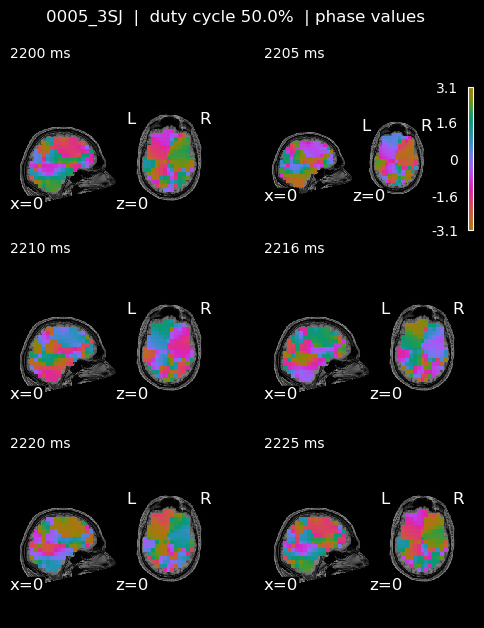

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


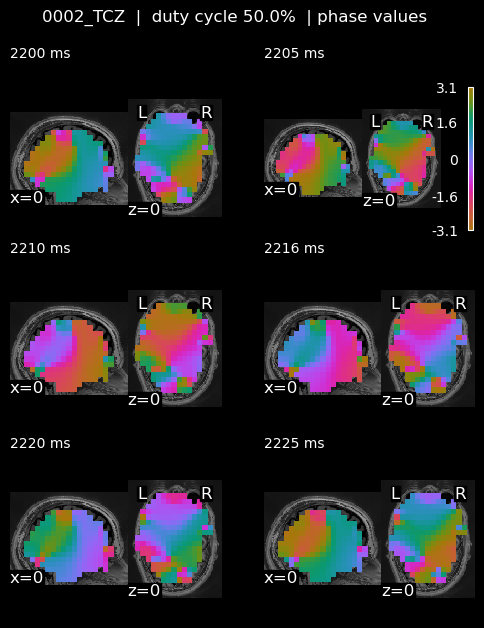

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0009_YGZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1225 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


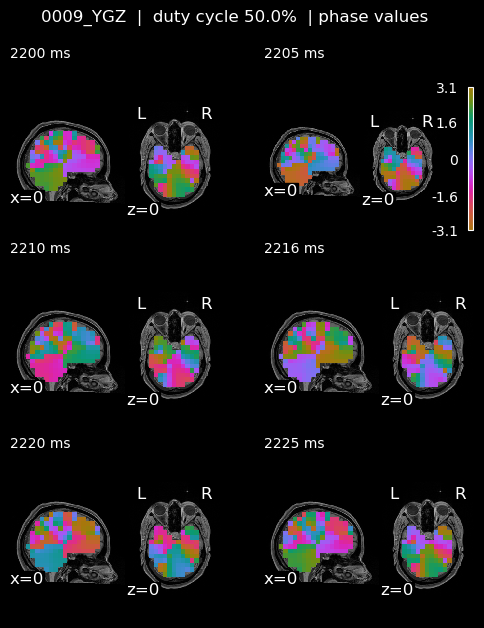

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0010_ZMG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1212 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


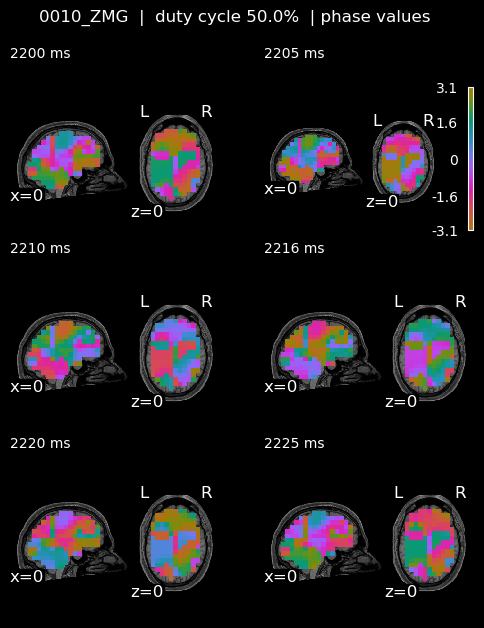

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0011_MEE-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1471 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


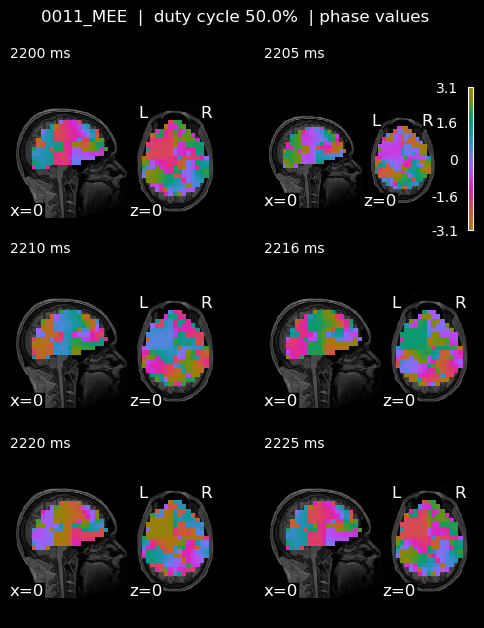

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0012_C3Z-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1311 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


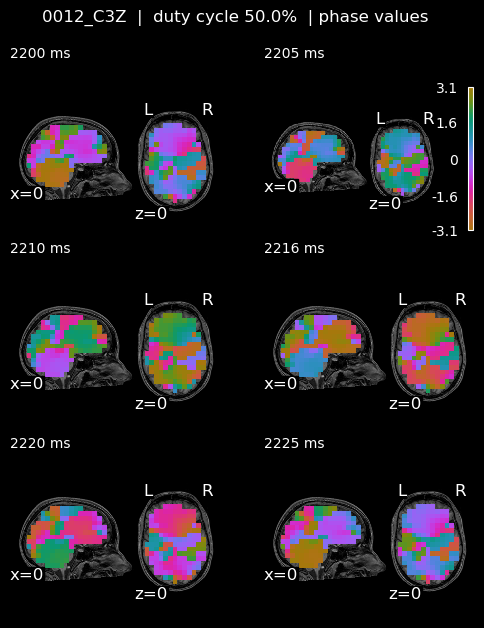

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0014_TAG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1211 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


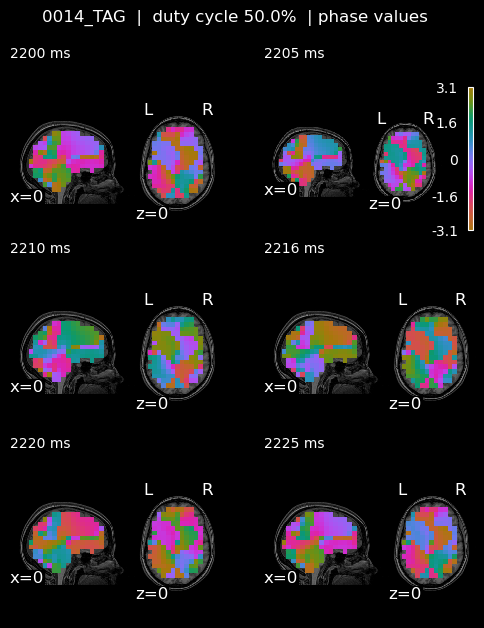

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0015_QKW-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1233 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


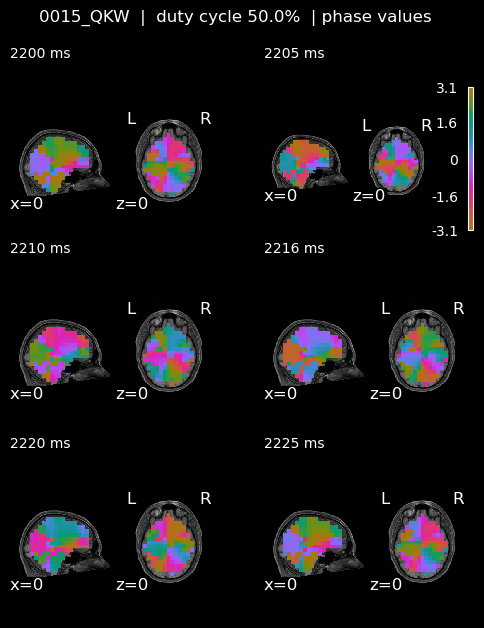

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0016_XLZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1124 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


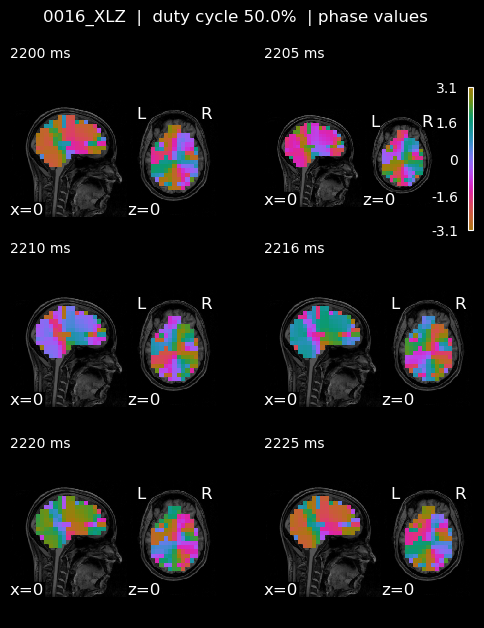

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0017_QJ5-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1212 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


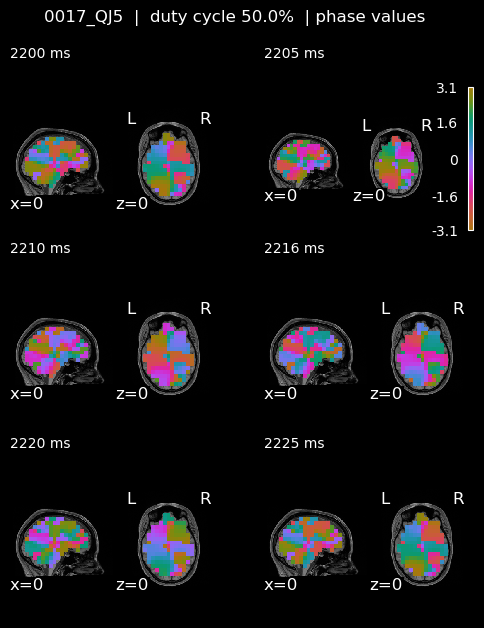

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0018_5T3-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1546 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


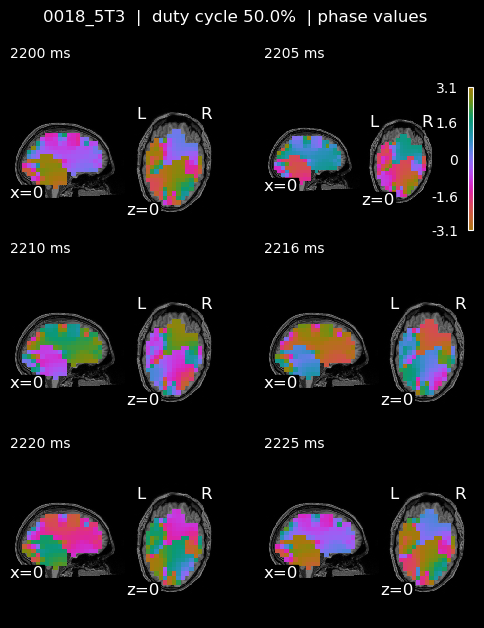

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0019_COG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1446 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


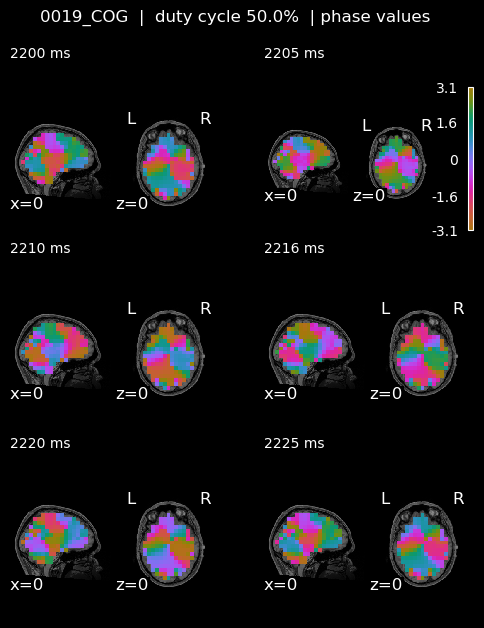

In [3]:
for subject_index in ss['subject_idx_list']:
    subject = ss['subject_id_list'][subject_index]
    hilbert_stc_file = Path(ss['hilbert_dir']) / subject / event_name / f"{subject}-trial-{trial}-hilbert-vol.stc"
    stc = mne.read_source_estimate(hilbert_stc_file)

    fwd = hf.load_fwd_model(subject_index)
    src = fwd['src']

    stcs = []
    t_points = []

    for i in range(6):
        t_point = tmin+(i*0.005)
        time_point_stc = stc.copy().crop(tmin=t_point, tmax=t_point)
        stcs.append(time_point_stc)
        t_points.append(f"{math.ceil(t_point*1000)} ms")

    test_circ_plot.plot_circ_stat_map(
        stcs=stcs,
        src=src,
        subject=subject,
        display_mode="xz",
        subjects_dir=ss['fs_subjects_dir'],
        title=f'{subject}  |  duty cycle {duty_cycle}%  | phase values',
        fig_titles=t_points,
        nrows=3,
        ncols=2,
        figsize=figsize,
        cut_coords=cut_coords,
        dpi=dpi,

    )

In [4]:
tmin = -0.4

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0005_3SJ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1440 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


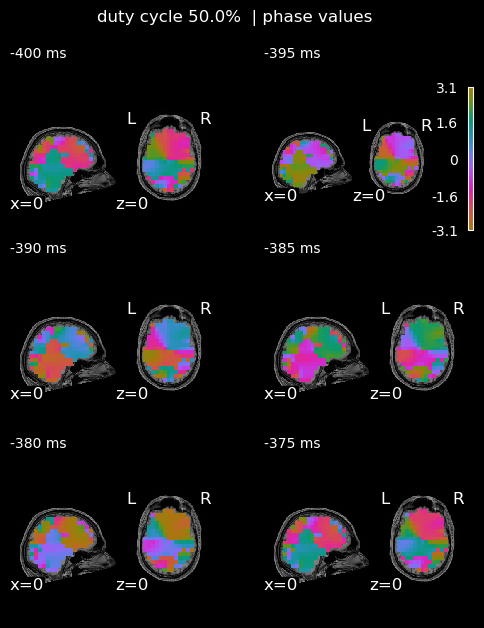

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0002_TCZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1868 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


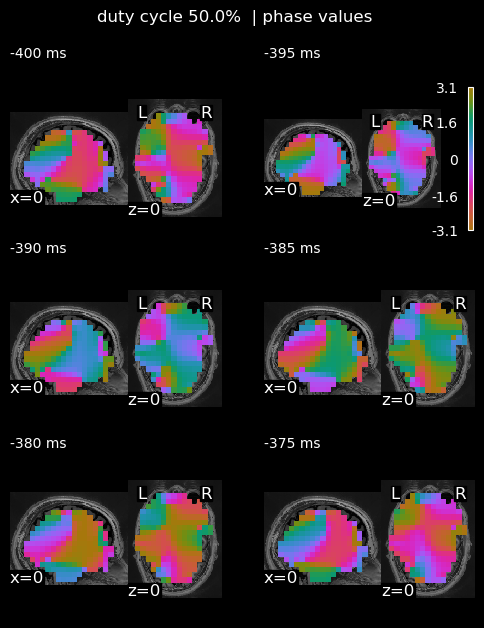

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0009_YGZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1225 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


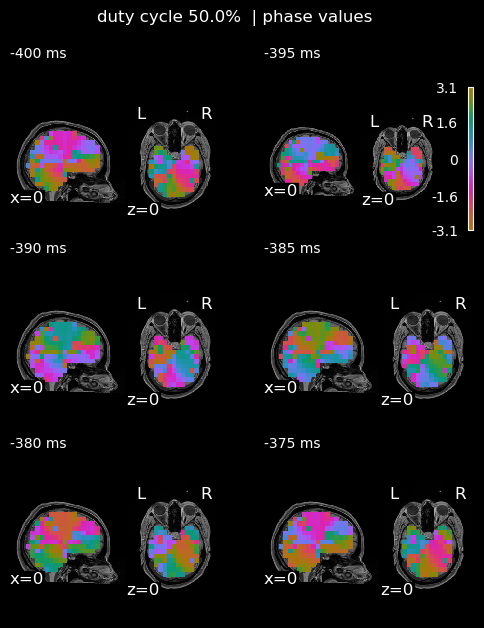

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0010_ZMG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1212 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


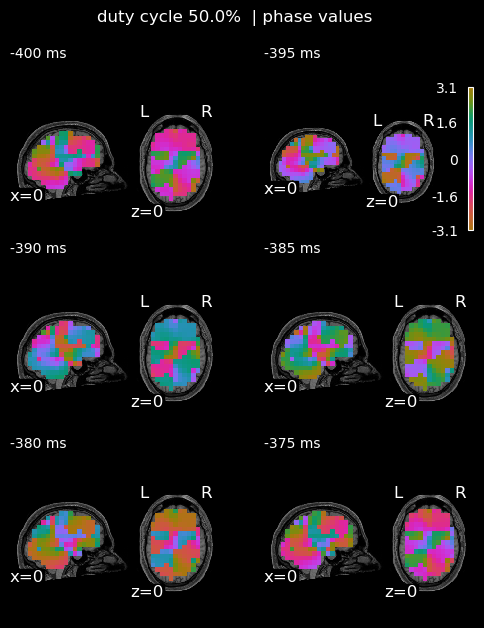

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0011_MEE-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1471 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


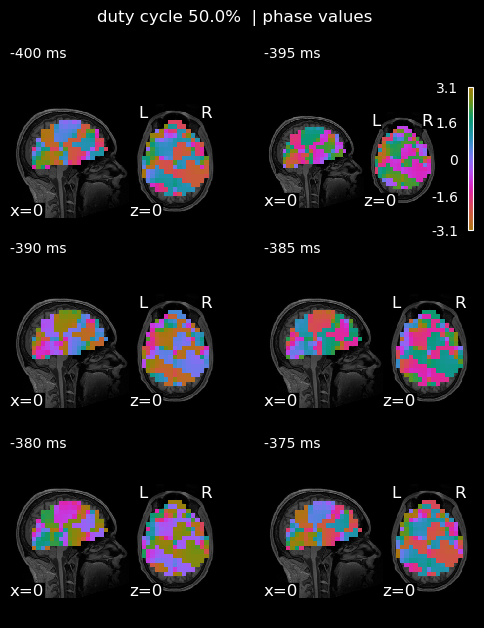

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0012_C3Z-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1311 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


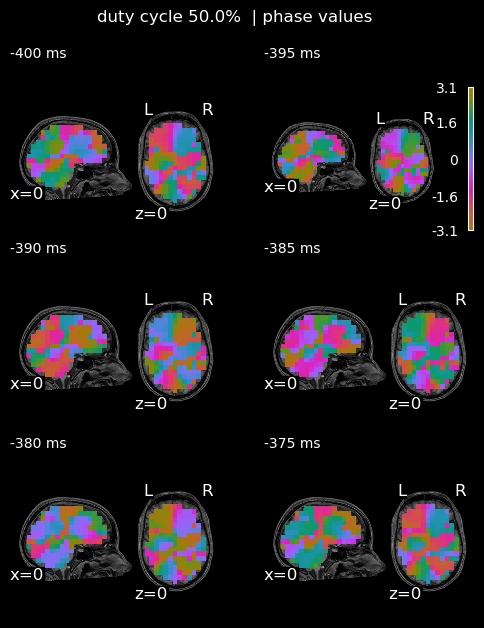

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0014_TAG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1211 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


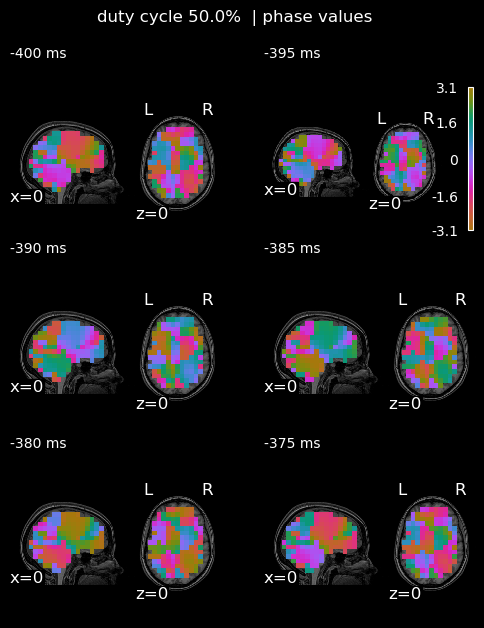

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0015_QKW-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1233 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


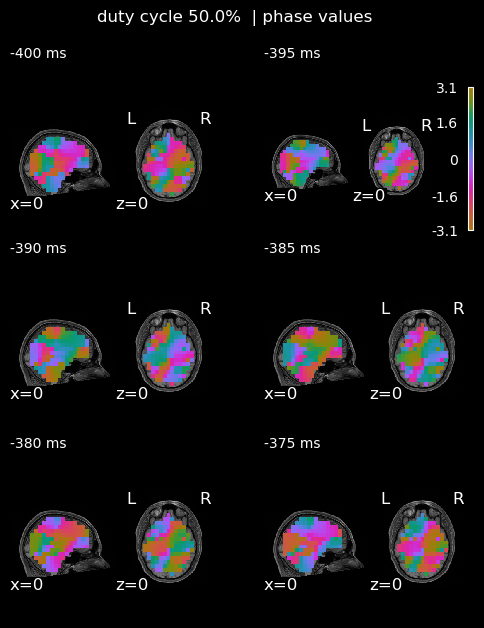

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0016_XLZ-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1124 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


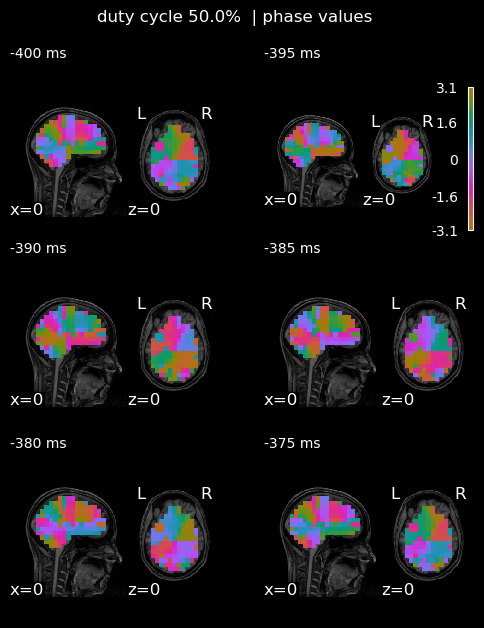

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0017_QJ5-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1212 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


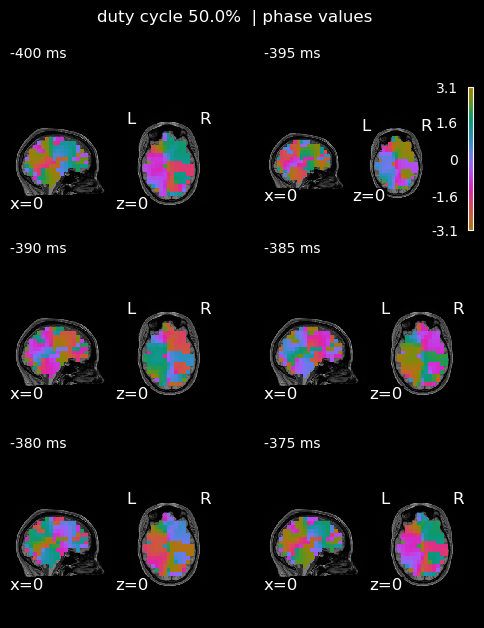

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0018_5T3-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1546 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


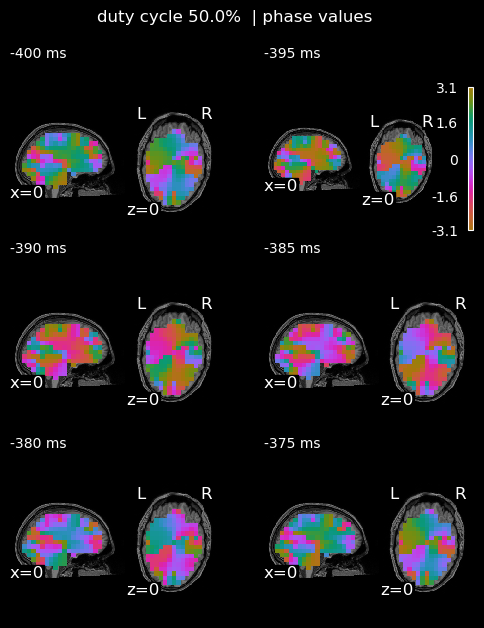

Reading forward solution from /media/elias/data/thesis_intermediate/data/scratch/fwd/0019_COG-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (1446 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


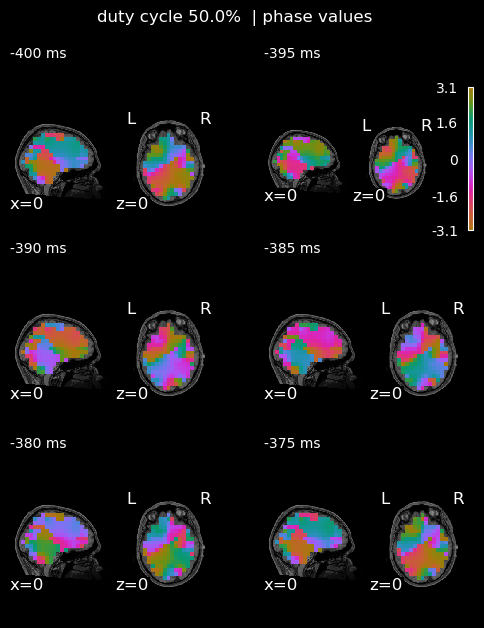

In [5]:
for subject_index in ss['subject_idx_list']:
    subject = ss['subject_id_list'][subject_index]
    hilbert_stc_file = Path(ss['hilbert_dir']) / subject / event_name / f"{subject}-trial-{trial}-hilbert-vol.stc"
    stc = mne.read_source_estimate(hilbert_stc_file)

    fwd = hf.load_fwd_model(subject_index)
    src = fwd['src']

    stcs = []
    t_points = []

    for i in range(6):
        t_point = tmin+(i*0.005)
        time_point_stc = stc.copy().crop(tmin=t_point, tmax=t_point)
        stcs.append(time_point_stc)
        t_points.append(f"{math.ceil(t_point*1000)} ms")

    test_circ_plot.plot_circ_stat_map(
        stcs=stcs,
        src=src,
        subject=subject,
        display_mode="xz",
        subjects_dir=ss['fs_subjects_dir'],
        title=f'{subject}  |  duty cycle {duty_cycle}%  | phase values',
        fig_titles=t_points,
        nrows=3,
        ncols=2,
        figsize=figsize,
        cut_coords=cut_coords,
        dpi=dpi,

    )